In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, pointbiserialr
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

pd.set_option('display.max_columns', None)

In [2]:
# 데이터 로드
df = pd.read_csv('../data/hotel_bookings.csv')
print(f"데이터 shape: {df.shape}")
df.head()

데이터 shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 1. 새로운 피처 생성

In [3]:
# 숙박 관련 피처
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['weekend_ratio'] = df['stays_in_weekend_nights'] / (df['total_nights'] + 1)
df['is_long_stay'] = (df['total_nights'] >= 7).astype(int)

# 고객 인원 관련
df['total_guests'] = df['adults'] + df['children'] + df['babies']
df['is_family'] = ((df['children'] > 0) | (df['babies'] > 0)).astype(int)
df['is_solo'] = (df['total_guests'] == 1).astype(int)
df['adr_per_person'] = df['adr'] / (df['total_guests'] + 1)

# 예약 사전성
df['is_last_minute'] = (df['lead_time'] <= 3).astype(int)
df['is_planned'] = (df['lead_time'] >= 90).astype(int)

# 예약 이력
df['has_previous_bookings'] = (df['previous_bookings_not_canceled'] > 0).astype(int)
df['previous_cancel_rate'] = df['previous_cancellations'] / (
    df['previous_cancellations'] + df['previous_bookings_not_canceled'] + 1
)
df['total_previous_bookings'] = df['previous_cancellations'] + df['previous_bookings_not_canceled']

# 예약 채널
df['has_agent'] = (df['agent'].notna() & (df['agent'] != 0)).astype(int)
df['has_company'] = (df['company'].notna() & (df['company'] != 0)).astype(int)
df['is_direct_booking'] = ((df['agent'].isna()) | (df['agent'] == 0)).astype(int)

# 특별 요청
df['has_special_requests'] = (df['total_of_special_requests'] > 0).astype(int)
df['needs_parking'] = (df['required_car_parking_spaces'] > 0).astype(int)
df['premium_service'] = (
    (df['total_of_special_requests'] >= 2) & 
    (df['required_car_parking_spaces'] > 0)
).astype(int)

# 금액 관련
df['total_revenue'] = df['adr'] * df['total_nights']
adr_75 = df['adr'].quantile(0.75)
df['is_high_price'] = (df['adr'] >= adr_75).astype(int)
df['is_free_stay'] = (df['adr'] == 0).astype(int)

# 도착 날짜
df['is_month_start'] = (df['arrival_date_day_of_month'] <= 7).astype(int)
df['is_month_end'] = (df['arrival_date_day_of_month'] >= 25).astype(int)
df['is_peak_season'] = df['arrival_date_month'].isin(['July', 'August', 'December']).astype(int)

# 복합 지표
df['high_risk_combo'] = (
    (df['deposit_type'] == 'No Deposit') & 
    (df['lead_time'] > 60) & 
    (df['is_repeated_guest'] == 0)
).astype(int)
df['trusted_customer'] = (
    (df['is_repeated_guest'] == 1) & 
    (df['previous_cancellations'] == 0)
).astype(int)

print(f"\n새로운 피처 생성 완료!")
print(f"총 컬럼 수: {len(df.columns)}개")


새로운 피처 생성 완료!
총 컬럼 수: 58개


## 2. 연속형 피처 - 상관계수 분석


=== 연속형 피처 상관계수 ===

                feature  correlation  abs_correlation
   previous_cancel_rate     0.285859         0.285859
          total_revenue     0.046562         0.046562
           total_guests     0.046506         0.046506
         adr_per_person     0.036259         0.036259
           total_nights     0.017779         0.017779
          weekend_ratio    -0.011550         0.011550
total_previous_bookings     0.003884         0.003884


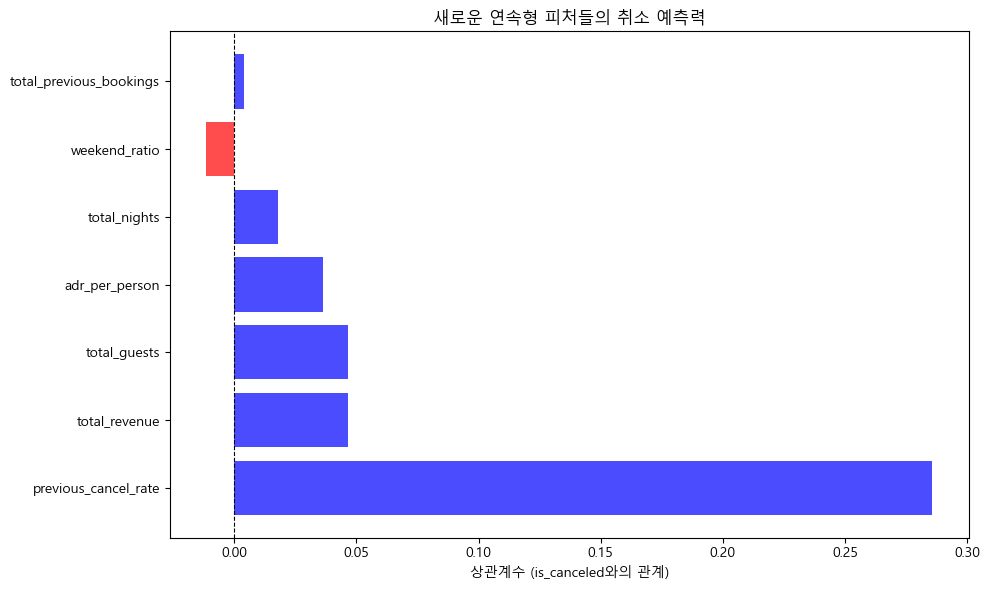

In [4]:
# 새로 생성한 연속형 피처들
continuous_features = [
    'total_nights', 'weekend_ratio', 'total_guests', 'adr_per_person',
    'previous_cancel_rate', 'total_previous_bookings', 'total_revenue'
]

# is_canceled와의 상관계수 계산
correlations = []
for feature in continuous_features:
    if df[feature].nunique() > 1:  # 분산이 0이 아닌 경우만
        corr = df[[feature, 'is_canceled']].corr().iloc[0, 1]
        correlations.append({'feature': feature, 'correlation': corr, 'abs_correlation': abs(corr)})

corr_df = pd.DataFrame(correlations).sort_values('abs_correlation', ascending=False)

print("\n=== 연속형 피처 상관계수 ===\n")
print(corr_df.to_string(index=False))

# 시각화
plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'blue' for x in corr_df['correlation']]
plt.barh(corr_df['feature'], corr_df['correlation'], color=colors, alpha=0.7)
plt.xlabel('상관계수 (is_canceled와의 관계)')
plt.title('새로운 연속형 피처들의 취소 예측력')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

## 3. 범주형 피처 - 카이제곱 검정

In [5]:
# 새로 생성한 범주형(이진) 피처들
categorical_features = [
    'is_long_stay', 'is_family', 'is_solo', 'is_last_minute', 'is_planned',
    'has_previous_bookings', 'has_agent', 'has_company', 'is_direct_booking',
    'has_special_requests', 'needs_parking', 'premium_service',
    'is_high_price', 'is_free_stay', 'is_month_start', 'is_month_end',
    'is_peak_season', 'high_risk_combo', 'trusted_customer'
]

# 카이제곱 검정 수행
chi2_results = []
for feature in categorical_features:
    contingency_table = pd.crosstab(df[feature], df['is_canceled'])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    
    # 취소율 차이 계산
    cancel_rate_0 = df[df[feature] == 0]['is_canceled'].mean()
    cancel_rate_1 = df[df[feature] == 1]['is_canceled'].mean()
    rate_diff = cancel_rate_1 - cancel_rate_0
    
    chi2_results.append({
        'feature': feature,
        'chi2_statistic': chi2,
        'p_value': p_value,
        'significant': '***' if p_value < 0.001 else ('**' if p_value < 0.01 else ('*' if p_value < 0.05 else '')),
        'cancel_rate_diff': rate_diff
    })

chi2_df = pd.DataFrame(chi2_results).sort_values('chi2_statistic', ascending=False)

print("\n=== 범주형 피처 카이제곱 검정 결과 ===\n")
print("(*** p<0.001, ** p<0.01, * p<0.05)\n")
print(chi2_df.to_string(index=False))


=== 범주형 피처 카이제곱 검정 결과 ===

(*** p<0.001, ** p<0.01, * p<0.05)

              feature  chi2_statistic       p_value significant  cancel_rate_diff
 has_special_requests     8364.468377  0.000000e+00         ***         -0.259809
           is_planned     7030.873772  0.000000e+00         ***          0.236681
       is_last_minute     5448.969613  0.000000e+00         ***         -0.323839
        needs_parking     4650.492526  0.000000e+00         ***         -0.394949
has_previous_bookings     1588.691228  0.000000e+00         ***         -0.325023
     trusted_customer     1456.067194  0.000000e+00         ***         -0.347592
            has_agent     1243.169913 2.531685e-272         ***          0.143410
    is_direct_booking     1243.169913 2.531685e-272         ***         -0.143410
          has_company     1176.593748 7.450277e-258         ***         -0.206975
      premium_service      907.839837 1.938843e-199         ***         -0.375212
              is_solo      766.267

## 4. Point-Biserial 상관계수 (이진 피처)


=== Point-Biserial 상관계수 (이진 피처) ===

              feature  pb_correlation  abs_correlation       p_value
 has_special_requests       -0.264706         0.264706  0.000000e+00
           is_planned        0.242690         0.242690  0.000000e+00
       is_last_minute       -0.213663         0.213663  0.000000e+00
        needs_parking       -0.197399         0.197399  0.000000e+00
has_previous_bookings       -0.115405         0.115405  0.000000e+00
     trusted_customer       -0.110491         0.110491 7.460391e-321
    is_direct_booking       -0.102068         0.102068 7.205191e-274
            has_agent        0.102068         0.102068 7.205191e-274
          has_company       -0.099310         0.099310 2.596754e-259
      premium_service       -0.087278         0.087278 1.532019e-200
              is_solo       -0.080136         0.080136 2.755490e-169
         is_free_stay       -0.069990         0.069990 1.622018e-129
      high_risk_combo       -0.032747         0.032747  1.070216e

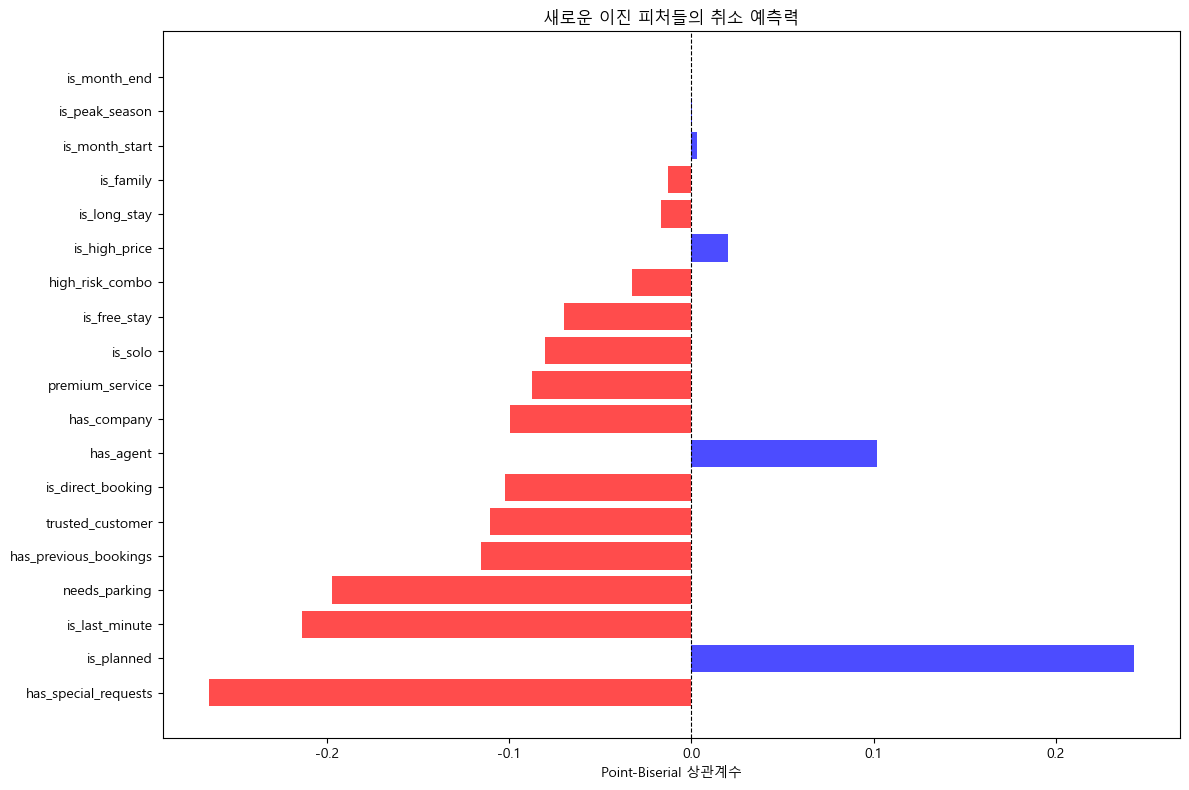

In [6]:
# Point-Biserial 상관계수 계산 (이진 변수 vs 이진 변수)
pb_results = []
for feature in categorical_features:
    if df[feature].nunique() == 2:  # 이진 변수인 경우만
        corr, p_value = pointbiserialr(df[feature], df['is_canceled'])
        pb_results.append({
            'feature': feature,
            'pb_correlation': corr,
            'abs_correlation': abs(corr),
            'p_value': p_value
        })

pb_df = pd.DataFrame(pb_results).sort_values('abs_correlation', ascending=False)

print("\n=== Point-Biserial 상관계수 (이진 피처) ===\n")
print(pb_df.to_string(index=False))

# 시각화
plt.figure(figsize=(12, 8))
colors = ['red' if x < 0 else 'blue' for x in pb_df['pb_correlation']]
plt.barh(pb_df['feature'], pb_df['pb_correlation'], color=colors, alpha=0.7)
plt.xlabel('Point-Biserial 상관계수')
plt.title('새로운 이진 피처들의 취소 예측력')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

## 5. TOP 10 유의미한 피처 선정


=== TOP 10 유의미한 피처 ===

              feature  correlation  abs_correlation type
 previous_cancel_rate     0.285859         0.285859  연속형
 has_special_requests    -0.264706         0.264706  이진형
           is_planned     0.242690         0.242690  이진형
       is_last_minute    -0.213663         0.213663  이진형
        needs_parking    -0.197399         0.197399  이진형
has_previous_bookings    -0.115405         0.115405  이진형
     trusted_customer    -0.110491         0.110491  이진형
    is_direct_booking    -0.102068         0.102068  이진형
            has_agent     0.102068         0.102068  이진형
          has_company    -0.099310         0.099310  이진형


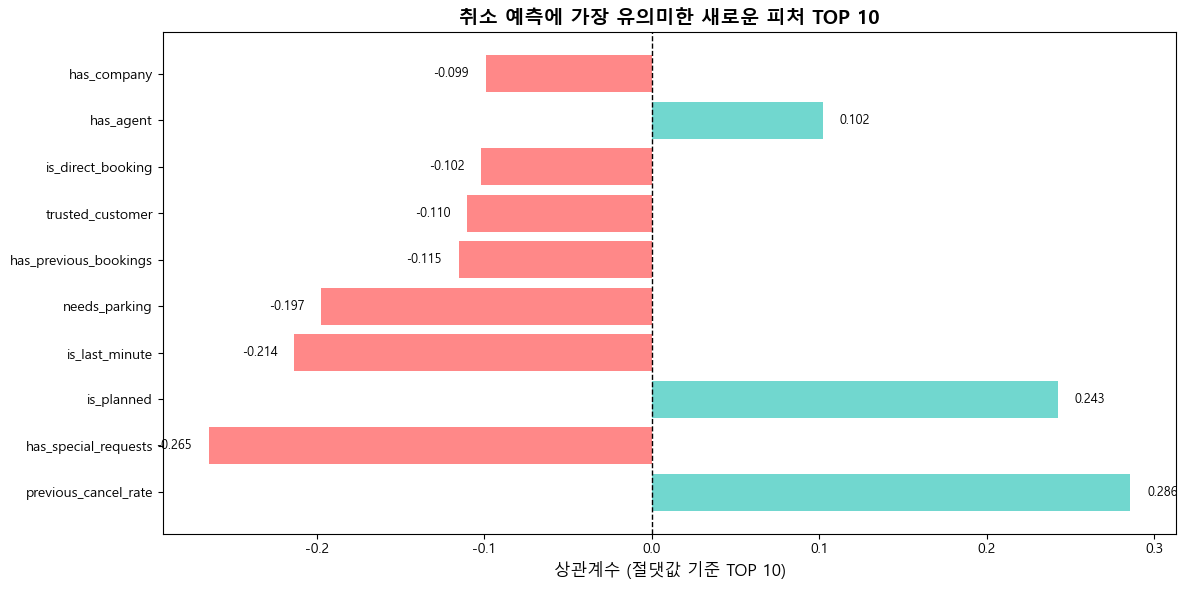

In [7]:
# 연속형과 이진형 피처의 절대 상관계수 합치기
all_correlations = []

# 연속형 피처
for _, row in corr_df.iterrows():
    all_correlations.append({
        'feature': row['feature'],
        'correlation': row['correlation'],
        'abs_correlation': row['abs_correlation'],
        'type': '연속형'
    })

# 이진형 피처
for _, row in pb_df.iterrows():
    all_correlations.append({
        'feature': row['feature'],
        'correlation': row['pb_correlation'],
        'abs_correlation': row['abs_correlation'],
        'type': '이진형'
    })

all_corr_df = pd.DataFrame(all_correlations).sort_values('abs_correlation', ascending=False)

print("\n=== TOP 10 유의미한 피처 ===\n")
print(all_corr_df.head(10).to_string(index=False))

# TOP 10 시각화
top10 = all_corr_df.head(10)
plt.figure(figsize=(12, 6))
colors = ['#ff6b6b' if x < 0 else '#4ecdc4' for x in top10['correlation']]
bars = plt.barh(top10['feature'], top10['correlation'], color=colors, alpha=0.8)
plt.xlabel('상관계수 (절댓값 기준 TOP 10)', fontsize=12)
plt.title('취소 예측에 가장 유의미한 새로운 피처 TOP 10', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

# 값 표시
for i, (bar, val) in enumerate(zip(bars, top10['correlation'])):
    plt.text(val + (0.01 if val > 0 else -0.01), bar.get_y() + bar.get_height()/2, 
             f'{val:.3f}', va='center', ha='left' if val > 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

## 6. 취소율 비교 분석 (주요 피처)

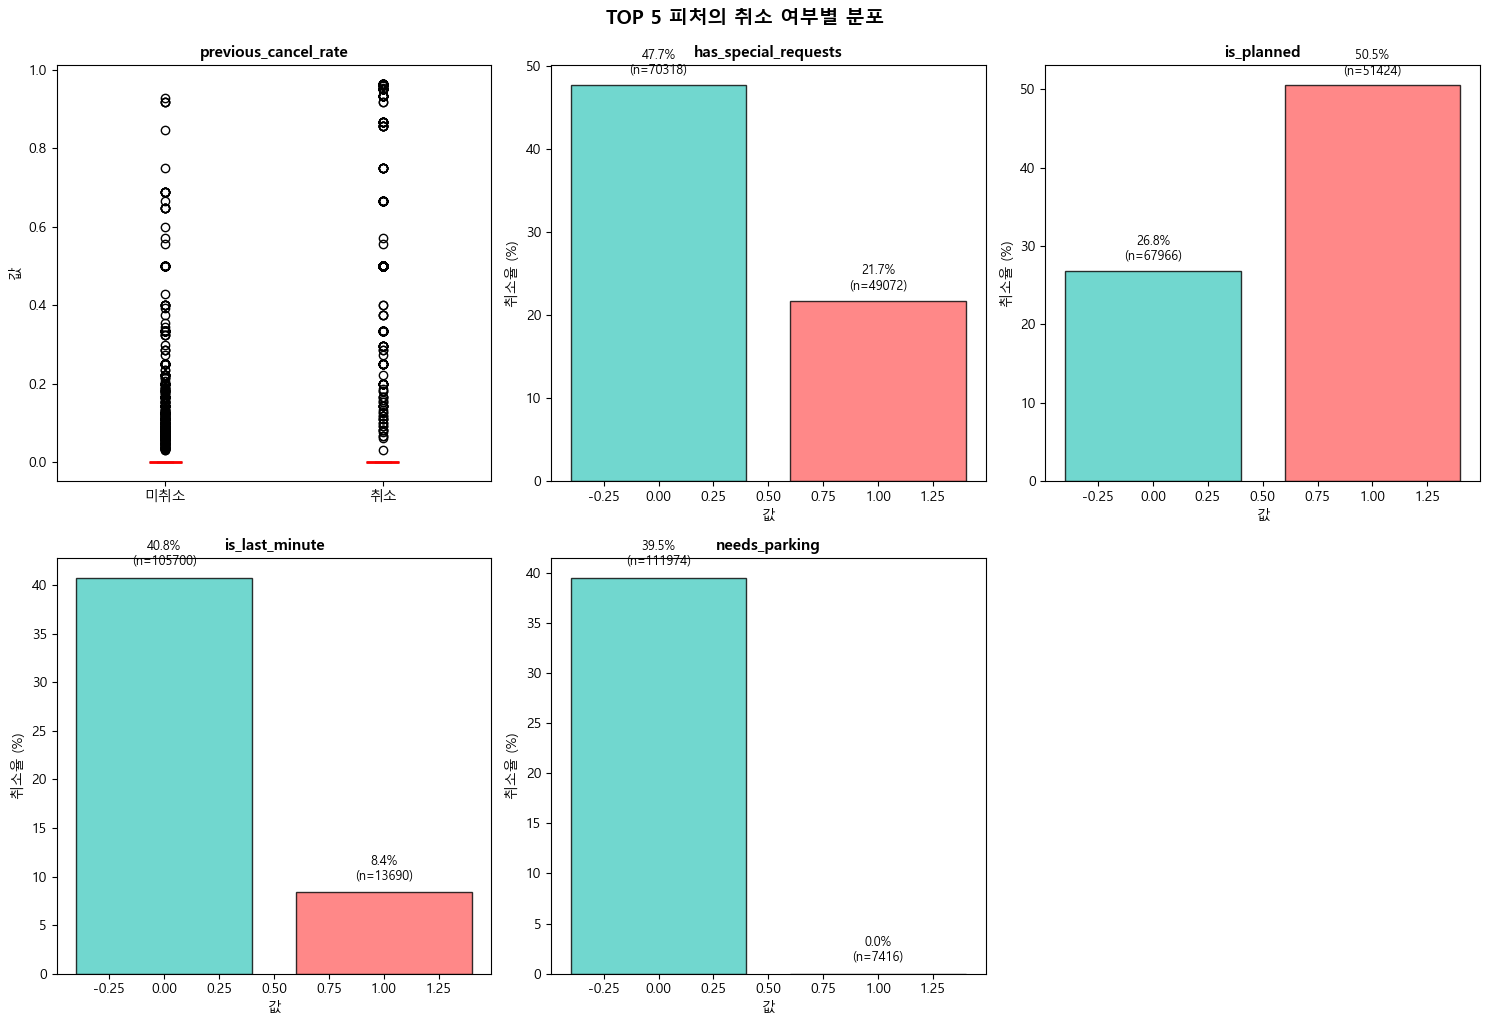

In [8]:
# TOP 5 피처에 대한 취소율 비교
top5_features = all_corr_df.head(5)['feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(top5_features):
    if df[feature].dtype in ['int64', 'float64'] and df[feature].nunique() <= 2:
        # 이진 피처
        cancel_rates = df.groupby(feature)['is_canceled'].agg(['mean', 'count'])
        cancel_rates['mean'] *= 100  # 퍼센트로 변환
        
        axes[idx].bar(cancel_rates.index, cancel_rates['mean'], 
                      color=['#4ecdc4', '#ff6b6b'], alpha=0.8, edgecolor='black')
        axes[idx].set_title(f'{feature}', fontsize=11, fontweight='bold')
        axes[idx].set_ylabel('취소율 (%)', fontsize=10)
        axes[idx].set_xlabel('값', fontsize=10)
        
        # 값 표시
        for i, (idx_val, row) in enumerate(cancel_rates.iterrows()):
            axes[idx].text(i, row['mean'] + 1, f"{row['mean']:.1f}%\n(n={int(row['count'])})",
                          ha='center', va='bottom', fontsize=9)
    else:
        # 연속형 피처
        df_temp = df[[feature, 'is_canceled']].copy()
        axes[idx].boxplot([df_temp[df_temp['is_canceled']==0][feature],
                          df_temp[df_temp['is_canceled']==1][feature]],
                         labels=['미취소', '취소'],
                         patch_artist=True,
                         boxprops=dict(facecolor='#4ecdc4', alpha=0.7),
                         medianprops=dict(color='red', linewidth=2))
        axes[idx].set_title(f'{feature}', fontsize=11, fontweight='bold')
        axes[idx].set_ylabel('값', fontsize=10)

# 마지막 빈 subplot 제거
if len(top5_features) < 6:
    fig.delaxes(axes[5])

plt.tight_layout()
plt.suptitle('TOP 5 피처의 취소 여부별 분포', fontsize=14, fontweight='bold', y=1.02)
plt.show()

## 7. 결론 및 추천 피처

In [9]:
print("\n" + "="*60)
print("📊 피처 엔지니어링 분석 결과 요약")
print("="*60 + "\n")

print("✅ 모델에 추가할 것을 강력 추천하는 피처 (절대 상관계수 > 0.05):")
recommended = all_corr_df[all_corr_df['abs_correlation'] > 0.05]
for idx, row in recommended.iterrows():
    print(f"  • {row['feature']:<30} (상관계수: {row['correlation']:>7.4f}, 타입: {row['type']})")

print("\n⚠️  보통 수준의 피처 (0.02 < 절대 상관계수 <= 0.05):")
moderate = all_corr_df[(all_corr_df['abs_correlation'] > 0.02) & (all_corr_df['abs_correlation'] <= 0.05)]
for idx, row in moderate.iterrows():
    print(f"  • {row['feature']:<30} (상관계수: {row['correlation']:>7.4f}, 타입: {row['type']})")

print("\n❌ 효과가 미미한 피처 (절대 상관계수 <= 0.02):")
weak = all_corr_df[all_corr_df['abs_correlation'] <= 0.02]
for idx, row in weak.iterrows():
    print(f"  • {row['feature']:<30} (상관계수: {row['correlation']:>7.4f}, 타입: {row['type']})")

print("\n" + "="*60)
print(f"💡 총 {len(recommended)}개의 피처를 v1.py에 추가하는 것을 추천합니다.")
print("="*60)


📊 피처 엔지니어링 분석 결과 요약

✅ 모델에 추가할 것을 강력 추천하는 피처 (절대 상관계수 > 0.05):
  • previous_cancel_rate           (상관계수:  0.2859, 타입: 연속형)
  • has_special_requests           (상관계수: -0.2647, 타입: 이진형)
  • is_planned                     (상관계수:  0.2427, 타입: 이진형)
  • is_last_minute                 (상관계수: -0.2137, 타입: 이진형)
  • needs_parking                  (상관계수: -0.1974, 타입: 이진형)
  • has_previous_bookings          (상관계수: -0.1154, 타입: 이진형)
  • trusted_customer               (상관계수: -0.1105, 타입: 이진형)
  • is_direct_booking              (상관계수: -0.1021, 타입: 이진형)
  • has_agent                      (상관계수:  0.1021, 타입: 이진형)
  • has_company                    (상관계수: -0.0993, 타입: 이진형)
  • premium_service                (상관계수: -0.0873, 타입: 이진형)
  • is_solo                        (상관계수: -0.0801, 타입: 이진형)
  • is_free_stay                   (상관계수: -0.0700, 타입: 이진형)

⚠️  보통 수준의 피처 (0.02 < 절대 상관계수 <= 0.05):
  • total_revenue                  (상관계수:  0.0466, 타입: 연속형)
  • total_guests                   (상관계수:  0.0465, 타입: 